## Imagery layers

In [41]:
import arcgis
from arcgis.gis import GIS
from IPython.display import display

gis = GIS()

Here we're searchcing for multispectral landsat imagery layer:

In [42]:
items = gis.content.search("Landsat 8 Views", max_items=2)

In [43]:
for item in items:
    display(item)

<Item title:"Imagery" type:Layer owner:esri>

<Item title:"Landsat 8 Views" type:Imagery Layer owner:esri>

In [44]:
landast_item = items[1]

In [46]:
imglyr = landast_item.layers[0]

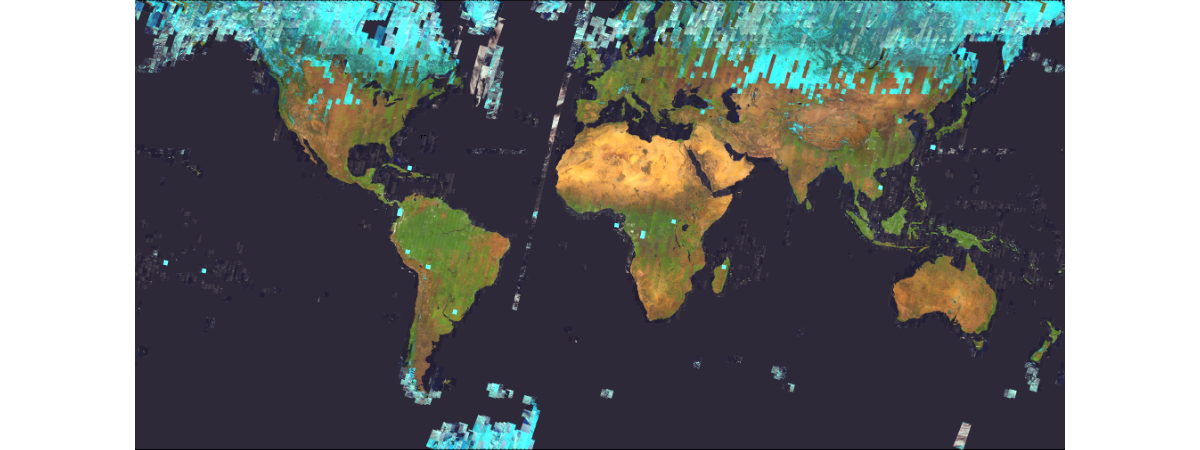

In [47]:
imglyr

Let us create a map widget and load this layer.

In [48]:
marthasbasin = arcgis.geocoding.geocode("Marthas Basin, Montana")[0]

In [49]:
map1 = gis.map(marthasbasin, zoomlevel=13)

In [50]:
map1

In [51]:
map1.add_layer(imglyr)

Here we are interactively cycling through these raster functions published with the layer and apply them to the map. This is using on-the-fly image processing at display resolution to cycle through the various raster functions, and showing how the visualization of the layer changes.

In [52]:
import time

for fn in imglyr.properties['rasterFunctionInfos'][:6]:
    print(fn['name'])
    map1.remove_layers()
    map1.add_layer(imglyr, {"imageServiceParameters" :{ "renderingRule": { "rasterFunction": fn['name']}}})
    time.sleep(2)

Agriculture with DRA
Bathymetric with DRA
Color Infrared with DRA
Natural Color with DRA
Short-wave Infrared with DRA
Geology with DRA


## Raster functions

Developers can create their own **raster functions**, by chaining different raster functions. For instance, the code below is doing an Extract Band and extracting out the [4,5,3] band combination, and applying a Stretch to get the land-water boundary visualization that makes it easy to see where land is and where water is. Its worth noting that the raster function is applied at display resolution and only for the visible extent using on the fly image processing.

In [54]:
from arcgis.raster.functions import stretch, extract_band

def process_bands(layer, bands):
    return stretch(extract_band(layer, bands), 
                    stretch_type='percentclip', min_percent=0.1, max_percent=0.1, gamma=[1, 1, 1], dra=True)

Let us apply this raster function to the image layer to visualize the results.

In [55]:
map2 = gis.map(marthasbasin, zoomlevel=13)
map2

In [56]:
map2.add_layer(process_bands(imglyr, [4, 5, 3]))

# Creating a Raster Information Product using Landsat 8 imagery

This part of the notebook shows how **Raster Analytics** (in ArcGIS Enterprise 10.5) can be used to generate a raster information product, by applying the same raster function across the extent of an image service on the portal. The raster function is applied at source resolution and creates an Information Product, that can be used for further analysis and visualization.

In [17]:
portal = GIS("https://dev003246.esri.com/portal", "admin")

<Item title:"ImgSrv_Landast_Montana2015" type:Imagery Layer owner:admin>
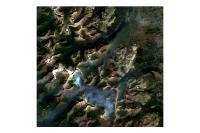

In [18]:
montana_landsat = portal.content.search("ImgSrv_Landast_Montana2015")[0]
montana_landsat

In [22]:
montana_lyr = montana_landsat.layers[0]

We can use the `arcgis.raster.analytics.generate_raster()` tool to apply the raster function across the entire extext of the input image layer at source resolution, and presist the result in another output image layer. This creates a raster product similar that can be used for further analysis and visualization.

In the code below, we use a raster function that extracts the [7, 5, 2] band combination. This improves visibility of fire and burn scars by pushing further into the SWIR range of the electromagnetic spectrum, as there is less susceptibility to smoke and haze generated by a burning fire.

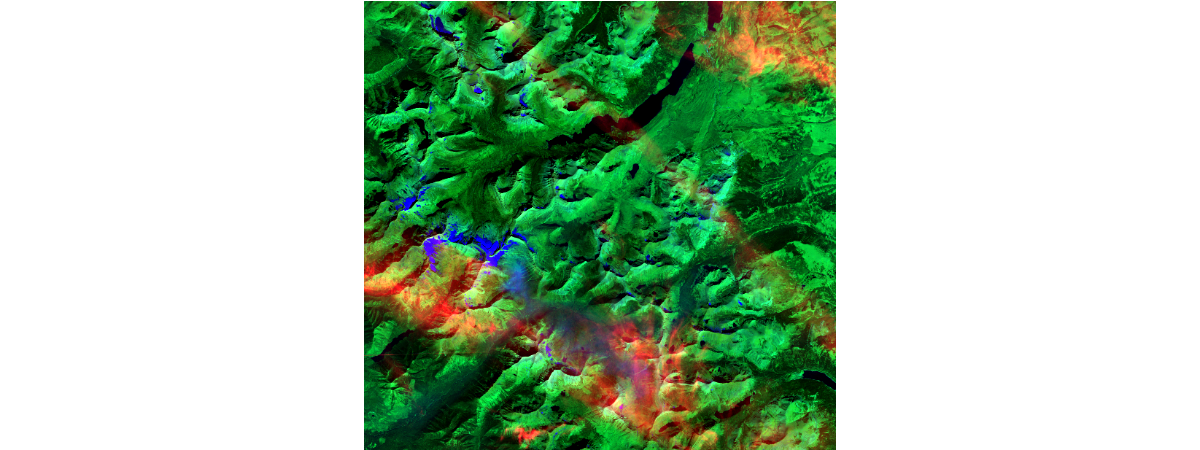

In [24]:
fire_viz = process_bands(montana_lyr, [7, 5, 2])
fire_viz

In [25]:
arcgis.env.verbose = True

In [26]:
montana_fires_lyr = fire_viz.save('Fire_Burn_scars')

Submitted.
Executing...
Executing (GenerateRaster): GenerateRaster {"rasterFunction":"Stretch","rasterFunctionArguments":{"MinPercent":0.1,"MaxPercent":0.1,"Raster":{"rasterFunction":"ExtractBand","rasterFunctionArguments":{"BandIDs":[7,5,2],"Raster":"https://dev003248.esri.com/rax/rest/services/ImgSrv_Landast_Montana2015/ImageServer"},"variableName":"Raster"},"Gamma":[1,1,1],"UseGamma":true,"DRA":true,"StretchType":6},"variableName":"Raster"} {"itemProperties":{"itemId":"1fd713d6de8f467cba4bf0813d45b525"},"serviceProperties":{"name":"Fire_Burn_scars","serviceUrl":"http://dev003248.esri.com/rax/rest/services/Hosted/Fire_Burn_scars/ImageServer"}} # # #
Start Time: Tue Jul 11 10:49:50 2017
Running script GenerateRaster...
Image service Fire_Burn_scars already existed.
GetPrivateUrl returns: https://dev003248.esri.com:6443/arcgis/rest/services/Hosted/Fire_Burn_scars/ImageServer
The service got from item ID is: https://dev003248.esri.com:6443/arcgis/rest/services/Hosted/Fire_Burn_scars/Ima

In [27]:
montana_fires_lyr

<Item title:"Fire_Burn_scars" type:Imagery Layer owner:admin>

In [40]:
location = arcgis.geocoding.geocode("Marthas Basin, Montana")[0]

base_map = portal.map(location, 12)

false_color_map = portal.map(location, 12)
false_color_map.add_layer(montana_fires_lyr)

In [36]:
false_color_map

Thus using the same raster function, we were able to both visualize on the fly (in the case of Pallikaranai marsh example) and also derive a persisted image layer (in the case of Montana example) with the power of raster analytics.